# 13 - Preprocessing the Data

This notebook is to preprocess the spectra! We shift, resample and normalize.

**Setup:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.constants import c
from scipy.interpolate import interp1d

import sys
import os
sys.path.append(os.path.abspath(".."))
import copy
import pickle

from src.aumic.data.preprocess import preprocess_orders, doppler_shift
from src.aumic.data.loader import load_file_list, load_metadata

from pathlib import Path

Loading and metadata:

In [2]:
vis_a_files = load_file_list("../../aumicAE/data/carvis_visA/vis_a_files.txt")
meta = load_metadata()

Checking the data:

In [3]:
with fits.open(vis_a_files[0]) as hdul:
    print(hdul.info())

Filename: ../../aumicAE/data/AUMic/CARVIS/car-20190714T01h22m54s-sci-gtoc-vis_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     465   ()      
  1  SPEC          1 ImageHDU         8   (4096, 61)   float32   
  2  CONT          1 ImageHDU         8   (4096, 61)   float32   
  3  SIG           1 ImageHDU         8   (4096, 61)   float32   
  4  WAVE          1 ImageHDU         8   (4096, 61)   float64   
None


This confirms that we are using the telluric corrected spectra!

**Define configuration:**

In [4]:
VALID_ORDERS = list(range(0, 61))

We do:

1. RV correction + edge trimming

2. Resample flux to common wavelength grid

3. Normalize spectra to have same mean

**Preprocessing for all 6 variants:**

In [5]:
Path("../outputs/preprocessed/").mkdir(parents=True, exist_ok=True)

#### With RV, unit variance

In [6]:
with_rv_unit, grids1 = preprocess_orders(vis_a_files, meta, VALID_ORDERS, use_rv=True, unit_variance=True)
with open("../outputs/preprocessed/with_rv_unit.pkl", "wb") as f:
    pickle.dump(with_rv_unit, f)

Adjusted pixel count to even: 4096, New crop range: (5136.59, 5226.43)
Adjusted pixel count to even: 4096, New crop range: (5180.51, 5271.08)
Adjusted pixel count to even: 4096, New crop range: (5225.17, 5316.51)
Adjusted pixel count to even: 4096, New crop range: (5270.62, 5362.73)
Adjusted pixel count to even: 4096, New crop range: (5316.86, 5409.76)
Adjusted pixel count to even: 4096, New crop range: (5363.92, 5457.62)
Adjusted pixel count to even: 4096, New crop range: (5411.83, 5506.34)
Adjusted pixel count to even: 4096, New crop range: (5460.59, 5555.93)
Adjusted pixel count to even: 4096, New crop range: (5510.24, 5606.43)
Adjusted pixel count to even: 4096, New crop range: (5560.80, 5657.85)
Adjusted pixel count to even: 4096, New crop range: (5612.30, 5710.23)
Adjusted pixel count to even: 4096, New crop range: (5664.76, 5763.58)
Adjusted pixel count to even: 4096, New crop range: (5718.21, 5817.94)
Adjusted pixel count to even: 4096, New crop range: (5772.67, 5873.34)
Adjust

#### With RV, variable variance

In [7]:
with_rv_var, grids2 = preprocess_orders(vis_a_files, meta, VALID_ORDERS, use_rv=True, unit_variance=False)
with open("../outputs/preprocessed/with_rv_var.pkl", "wb") as f:
    pickle.dump(with_rv_var, f)

Adjusted pixel count to even: 4096, New crop range: (5136.59, 5226.43)
Adjusted pixel count to even: 4096, New crop range: (5180.51, 5271.08)
Adjusted pixel count to even: 4096, New crop range: (5225.17, 5316.51)
Adjusted pixel count to even: 4096, New crop range: (5270.62, 5362.73)
Adjusted pixel count to even: 4096, New crop range: (5316.86, 5409.76)
Adjusted pixel count to even: 4096, New crop range: (5363.92, 5457.62)
Adjusted pixel count to even: 4096, New crop range: (5411.83, 5506.34)
Adjusted pixel count to even: 4096, New crop range: (5460.59, 5555.93)
Adjusted pixel count to even: 4096, New crop range: (5510.24, 5606.43)
Adjusted pixel count to even: 4096, New crop range: (5560.80, 5657.85)
Adjusted pixel count to even: 4096, New crop range: (5612.30, 5710.23)
Adjusted pixel count to even: 4096, New crop range: (5664.76, 5763.58)
Adjusted pixel count to even: 4096, New crop range: (5718.21, 5817.94)
Adjusted pixel count to even: 4096, New crop range: (5772.67, 5873.34)
Adjust

#### Without RV, unit variance

In [8]:
without_rv_unit, grids3 = preprocess_orders(vis_a_files, meta, VALID_ORDERS, use_rv=False, unit_variance=True)
with open("../outputs/preprocessed/without_rv_unit.pkl", "wb") as f:
    pickle.dump(without_rv_unit, f)

Adjusted pixel count to even: 4096, New crop range: (5136.51, 5226.36)
Adjusted pixel count to even: 4096, New crop range: (5180.42, 5271.01)
Adjusted pixel count to even: 4096, New crop range: (5225.09, 5316.44)
Adjusted pixel count to even: 4096, New crop range: (5270.53, 5362.66)
Adjusted pixel count to even: 4096, New crop range: (5316.77, 5409.69)
Adjusted pixel count to even: 4096, New crop range: (5363.84, 5457.55)
Adjusted pixel count to even: 4096, New crop range: (5411.74, 5506.26)
Adjusted pixel count to even: 4096, New crop range: (5460.50, 5555.86)
Adjusted pixel count to even: 4096, New crop range: (5510.15, 5606.35)
Adjusted pixel count to even: 4096, New crop range: (5560.71, 5657.78)
Adjusted pixel count to even: 4096, New crop range: (5612.20, 5710.15)
Adjusted pixel count to even: 4096, New crop range: (5664.66, 5763.50)
Adjusted pixel count to even: 4096, New crop range: (5718.11, 5817.87)
Adjusted pixel count to even: 4096, New crop range: (5772.58, 5873.26)
Adjust

#### Without RV, variable variance

In [9]:
without_rv_var, grids4 = preprocess_orders(vis_a_files, meta, VALID_ORDERS, use_rv=False, unit_variance=False)
with open("../outputs/preprocessed/without_rv_var.pkl", "wb") as f:
    pickle.dump(without_rv_var, f)

Adjusted pixel count to even: 4096, New crop range: (5136.51, 5226.36)
Adjusted pixel count to even: 4096, New crop range: (5180.42, 5271.01)
Adjusted pixel count to even: 4096, New crop range: (5225.09, 5316.44)
Adjusted pixel count to even: 4096, New crop range: (5270.53, 5362.66)
Adjusted pixel count to even: 4096, New crop range: (5316.77, 5409.69)
Adjusted pixel count to even: 4096, New crop range: (5363.84, 5457.55)
Adjusted pixel count to even: 4096, New crop range: (5411.74, 5506.26)
Adjusted pixel count to even: 4096, New crop range: (5460.50, 5555.86)
Adjusted pixel count to even: 4096, New crop range: (5510.15, 5606.35)
Adjusted pixel count to even: 4096, New crop range: (5560.71, 5657.78)
Adjusted pixel count to even: 4096, New crop range: (5612.20, 5710.15)
Adjusted pixel count to even: 4096, New crop range: (5664.66, 5763.50)
Adjusted pixel count to even: 4096, New crop range: (5718.11, 5817.87)
Adjusted pixel count to even: 4096, New crop range: (5772.58, 5873.26)
Adjust

#### With RV, raw (no mean subtraction, no variance normalization)

In [10]:
with_rv_raw, _ = preprocess_orders(vis_a_files, meta, VALID_ORDERS, use_rv=True, unit_variance=False, subtract_mean=False)
with open("../outputs/preprocessed/with_rv_raw.pkl", "wb") as f:
    pickle.dump(with_rv_raw, f)

Adjusted pixel count to even: 4096, New crop range: (5136.59, 5226.43)
Adjusted pixel count to even: 4096, New crop range: (5180.51, 5271.08)
Adjusted pixel count to even: 4096, New crop range: (5225.17, 5316.51)
Adjusted pixel count to even: 4096, New crop range: (5270.62, 5362.73)
Adjusted pixel count to even: 4096, New crop range: (5316.86, 5409.76)
Adjusted pixel count to even: 4096, New crop range: (5363.92, 5457.62)
Adjusted pixel count to even: 4096, New crop range: (5411.83, 5506.34)
Adjusted pixel count to even: 4096, New crop range: (5460.59, 5555.93)
Adjusted pixel count to even: 4096, New crop range: (5510.24, 5606.43)
Adjusted pixel count to even: 4096, New crop range: (5560.80, 5657.85)
Adjusted pixel count to even: 4096, New crop range: (5612.30, 5710.23)
Adjusted pixel count to even: 4096, New crop range: (5664.76, 5763.58)
Adjusted pixel count to even: 4096, New crop range: (5718.21, 5817.94)
Adjusted pixel count to even: 4096, New crop range: (5772.67, 5873.34)
Adjust

#### Without RV, raw

In [11]:
without_rv_raw, _ = preprocess_orders(vis_a_files, meta, VALID_ORDERS, use_rv=False, unit_variance=False, subtract_mean=False)
with open("../outputs/preprocessed/without_rv_raw.pkl", "wb") as f:
    pickle.dump(without_rv_raw, f)

Adjusted pixel count to even: 4096, New crop range: (5136.51, 5226.36)
Adjusted pixel count to even: 4096, New crop range: (5180.42, 5271.01)
Adjusted pixel count to even: 4096, New crop range: (5225.09, 5316.44)
Adjusted pixel count to even: 4096, New crop range: (5270.53, 5362.66)
Adjusted pixel count to even: 4096, New crop range: (5316.77, 5409.69)
Adjusted pixel count to even: 4096, New crop range: (5363.84, 5457.55)
Adjusted pixel count to even: 4096, New crop range: (5411.74, 5506.26)
Adjusted pixel count to even: 4096, New crop range: (5460.50, 5555.86)
Adjusted pixel count to even: 4096, New crop range: (5510.15, 5606.35)
Adjusted pixel count to even: 4096, New crop range: (5560.71, 5657.78)
Adjusted pixel count to even: 4096, New crop range: (5612.20, 5710.15)
Adjusted pixel count to even: 4096, New crop range: (5664.66, 5763.50)
Adjusted pixel count to even: 4096, New crop range: (5718.11, 5817.87)
Adjusted pixel count to even: 4096, New crop range: (5772.58, 5873.26)
Adjust

### **Normalized with Zero Mean vs. Raw**

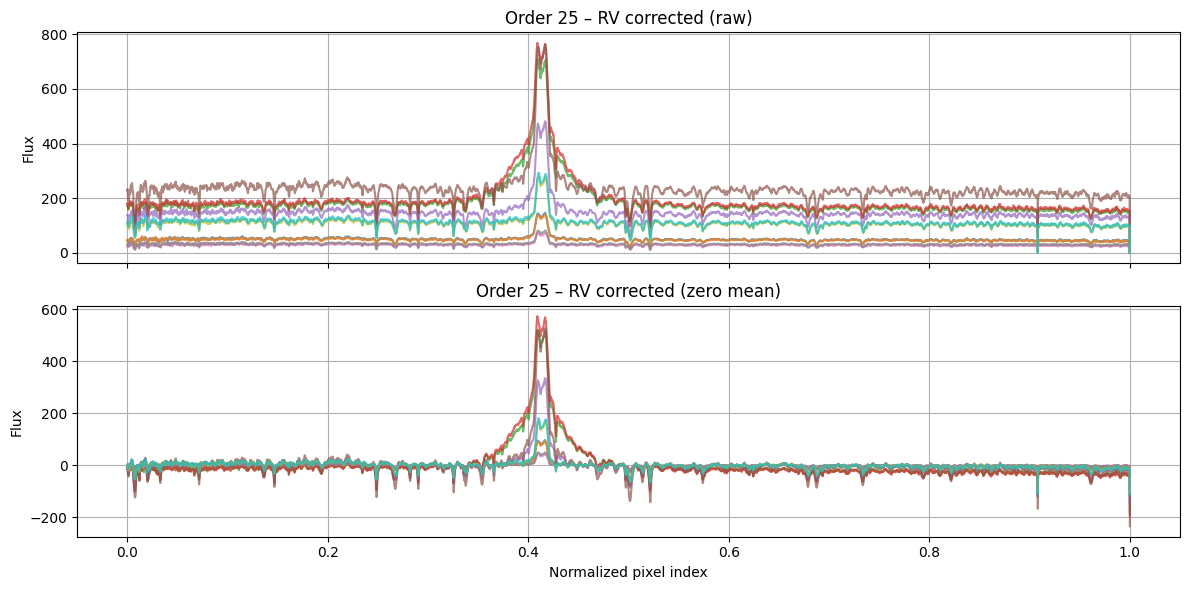

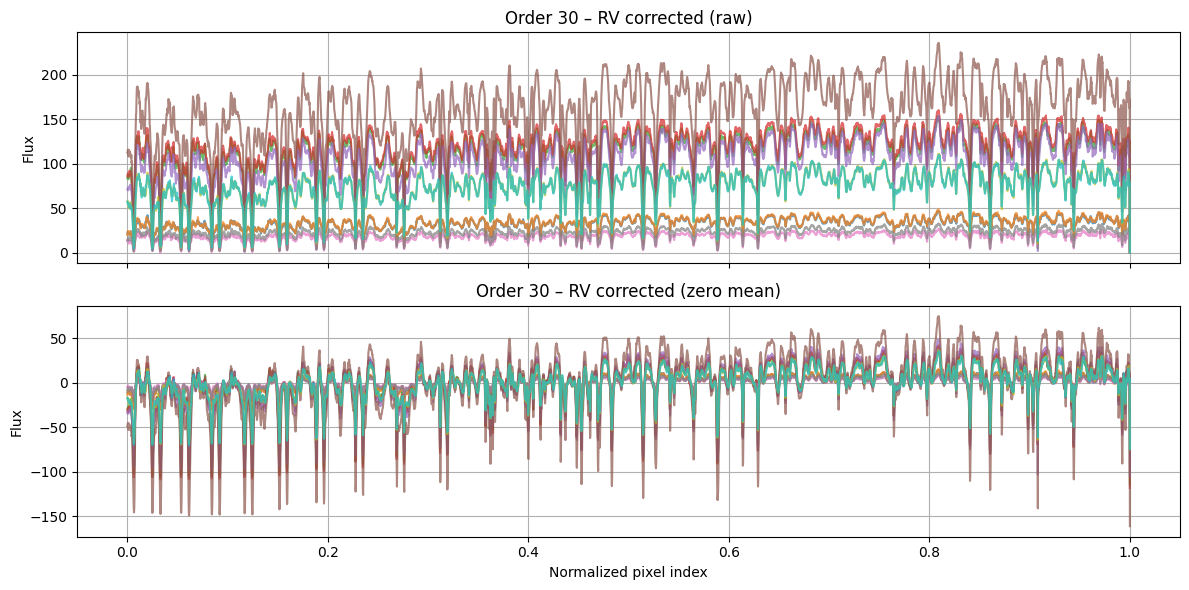

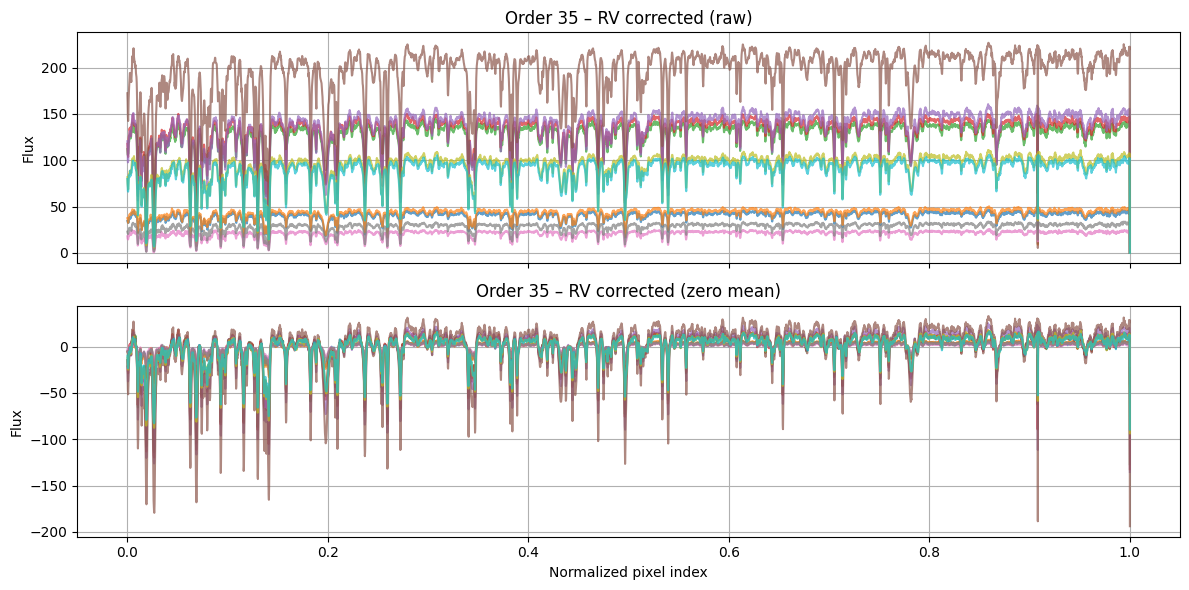

In [12]:
orders_to_plot = [25, 30, 35]
n_examples = 10

for order in orders_to_plot:
    raw = with_rv_raw[order]                  # No normalization
    zero_mean = with_rv_var[order]            # Only zero-mean applied
    wave = np.linspace(0, 1, raw.shape[1])    # Use same length for x-axis

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for i in range(n_examples):
        axs[0].plot(wave, raw[i], alpha=0.7)
        axs[1].plot(wave, zero_mean[i], alpha=0.7)

    axs[0].set_title(f"Order {order} – RV corrected (raw)")
    axs[1].set_title(f"Order {order} – RV corrected (zero mean)")
    axs[1].set_xlabel("Normalized pixel index")
    axs[0].set_ylabel("Flux")
    axs[1].set_ylabel("Flux")
    axs[0].grid(); axs[1].grid()
    plt.tight_layout()
    plt.show()

### **Normalized with Unit STD vs. Zero Mean only**

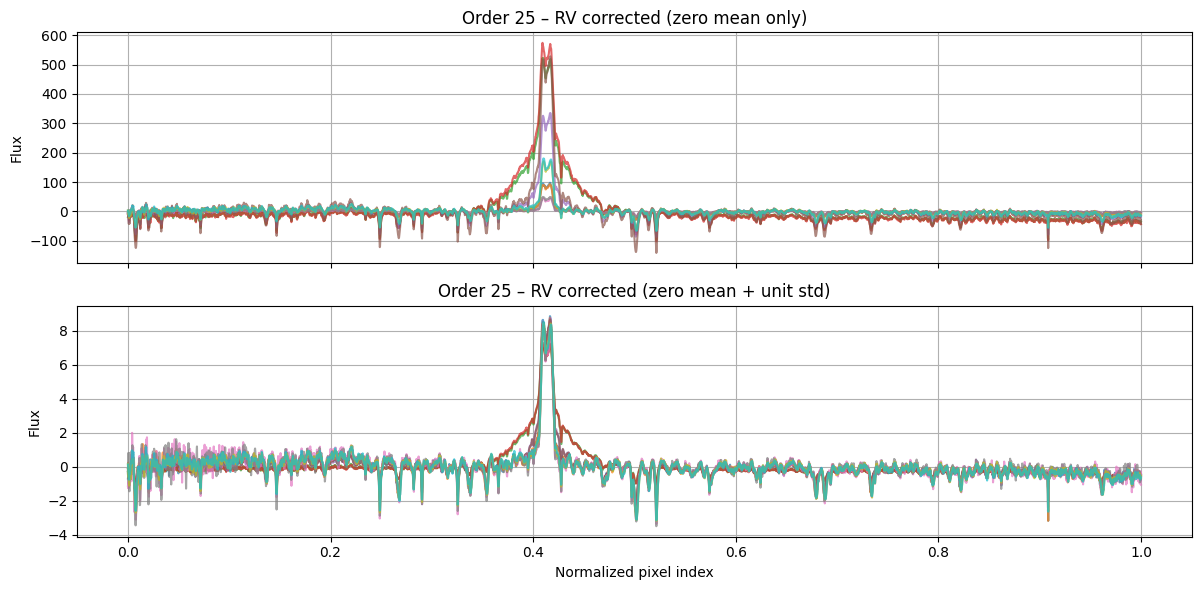

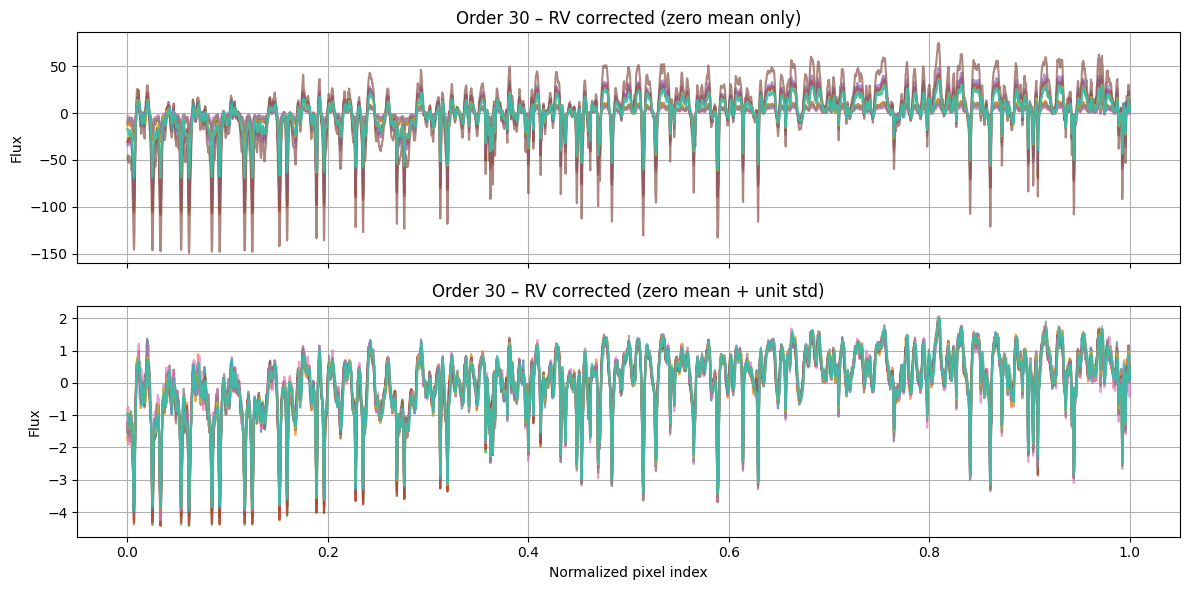

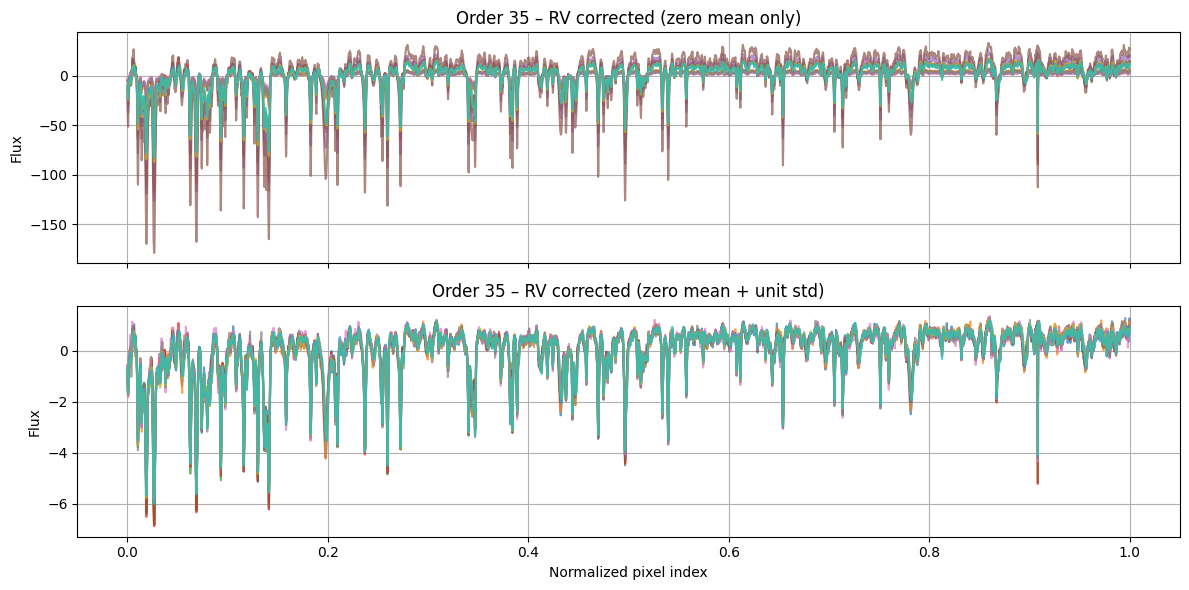

In [63]:
orders_to_plot = [25, 30, 35]
n_examples = 10

for order in orders_to_plot:
    normed = with_rv_unit[order]
    var_scaled = with_rv_var[order]
    wave = np.linspace(0, 1, normed.shape[1])

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for i in range(n_examples):
        axs[0].plot(wave, var_scaled[i], alpha=0.7)
        axs[1].plot(wave, normed[i], alpha=0.7)

    axs[0].set_title(f"Order {order} – RV corrected (zero mean only)")
    axs[1].set_title(f"Order {order} – RV corrected (zero mean + unit std)")
    axs[1].set_xlabel("Normalized pixel index")
    axs[0].set_ylabel("Flux")
    axs[1].set_ylabel("Flux")
    axs[0].grid(); axs[1].grid()
    plt.tight_layout()
    plt.show()

### **Cropped Order 32**

In [4]:
order_crop = {32: (7137.0, 7140.5)}

Path:

In [5]:
output_dir = "../outputs/preprocessed/cropped_order32"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Function to save both preprocessed and grid:

In [6]:
def save_both(data, grid, name):
    with open(f"{output_dir}/{name}.pkl", "wb") as f:
        pickle.dump({"spectra": data, "wavelengths": grid}, f)

Preprocess each and save:

In [7]:
with_rv_unit_32, grid = preprocess_orders(
    vis_a_files, meta, [32],
    use_rv=True, unit_variance=True, subtract_mean=True,
    order_ranges=order_crop, upsample_factor=1
)
save_both(with_rv_unit_32, grid, "with_rv_unit")

with_rv_var_32, grid = preprocess_orders(
    vis_a_files, meta, [32],
    use_rv=True, unit_variance=False, subtract_mean=True,
    order_ranges=order_crop, upsample_factor=1
)
save_both(with_rv_var_32, grid, "with_rv_var")

without_rv_unit_32, grid = preprocess_orders(
    vis_a_files, meta, [32],
    use_rv=False, unit_variance=True, subtract_mean=True,
    order_ranges=order_crop, upsample_factor=1
)
save_both(without_rv_unit_32, grid, "without_rv_unit")

without_rv_var_32, grid = preprocess_orders(
    vis_a_files, meta, [32],
    use_rv=False, unit_variance=False, subtract_mean=True,
    order_ranges=order_crop, upsample_factor=1
)
save_both(without_rv_var_32, grid, "without_rv_var")

with_rv_raw_32, grid = preprocess_orders(
    vis_a_files, meta, [32],
    use_rv=True, unit_variance=False, subtract_mean=False,
    order_ranges=order_crop, upsample_factor=1
)
save_both(with_rv_raw_32, grid, "with_rv_raw")

without_rv_raw_32, grid = preprocess_orders(
    vis_a_files, meta, [32],
    use_rv=False, unit_variance=False, subtract_mean=False,
    order_ranges=order_crop, upsample_factor=1
)
save_both(without_rv_raw_32, grid, "without_rv_raw")

Adjusted pixel count to even: 118, New crop range: (7137.00, 7140.53)
Adjusted pixel count to even: 118, New crop range: (7137.00, 7140.53)
Adjusted pixel count to even: 118, New crop range: (7137.00, 7140.53)
Adjusted pixel count to even: 118, New crop range: (7137.00, 7140.53)
Adjusted pixel count to even: 118, New crop range: (7137.00, 7140.53)
Adjusted pixel count to even: 118, New crop range: (7137.00, 7140.53)


### **To See Pure Normalization Effect**

(see outputs below)

In [ ]:
c_kms = c.to("km/s").value
def doppler_shift(wave, rv_kms):
    beta = rv_kms / c_kms
    gamma = np.sqrt((1 + beta) / (1 - beta))
    return wave * gamma

In [49]:
processed_with_rv = {}
processed_without_rv = {}
common_grids = {}

Loop to compute trimmed valid range across spectra (per order) and process through full cube:

In [ ]:
for order in VALID_ORDERS:
    # build common grid as usual using RV-corrected version
    shifted_grids = []
    for idx, f in enumerate(vis_a_files):
        with fits.open(f) as hdul:
            wave = hdul["WAVE"].data[order]
            rv = meta.loc[idx, "RV"]
            shifted_wave = doppler_shift(wave, -rv)
            shifted_grids.append(shifted_wave)
    
    min_wave = max(w[0] for w in shifted_grids)
    max_wave = min(w[-1] for w in shifted_grids)
    grid = np.linspace(min_wave, max_wave, len(shifted_grids[0]))
    common_grids[order] = grid

    with_rv = []
    without_rv = []

    for idx, f in enumerate(vis_a_files):
        with fits.open(f) as hdul:
            wave = hdul["WAVE"].data[order]
            flux = hdul["SPEC"].data[order]
            cont = hdul["CONT"].data[order]
            norm_flux = flux / np.clip(cont, 1e-3, np.inf)
            norm_flux = np.nan_to_num(norm_flux)

        rv = meta.loc[idx, "RV"]
        wave_shifted = doppler_shift(wave, -rv)

        # Interpolate to same grid
        interp_rv = interp1d(wave_shifted, norm_flux, bounds_error=False, fill_value=0.0)
        interp_norv = interp1d(wave, norm_flux, bounds_error=False, fill_value=0.0)

        with_rv.append(interp_rv(grid))
        without_rv.append(interp_norv(grid))

    # Convert to arrays
    with_rv = np.array(with_rv)
    without_rv = np.array(without_rv)

    # Normalize each spectrum (zero mean, unit std)
    def normalize(X):
        m = np.mean(X, axis=1, keepdims=True)
        s = np.std(X, axis=1, keepdims=True)
        return (X - m) / s

    processed_with_rv[order] = normalize(with_rv)
    processed_without_rv[order] = normalize(without_rv)

### Plot Preprocessed Spectra

In [ ]:
with open("../outputs/preprocessed/with_rv_unit.pkl", "rb") as f:
    processed_with_rv = pickle.load(f)

**Comparison Plot**

The grid is normlized to 0,1 but for plotting only.

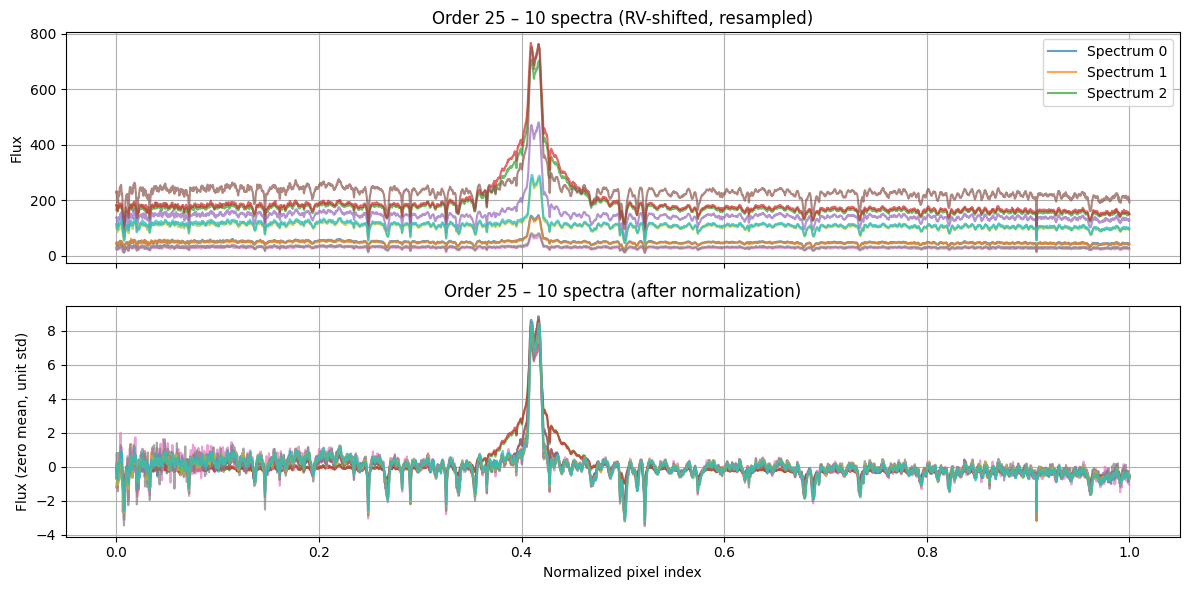

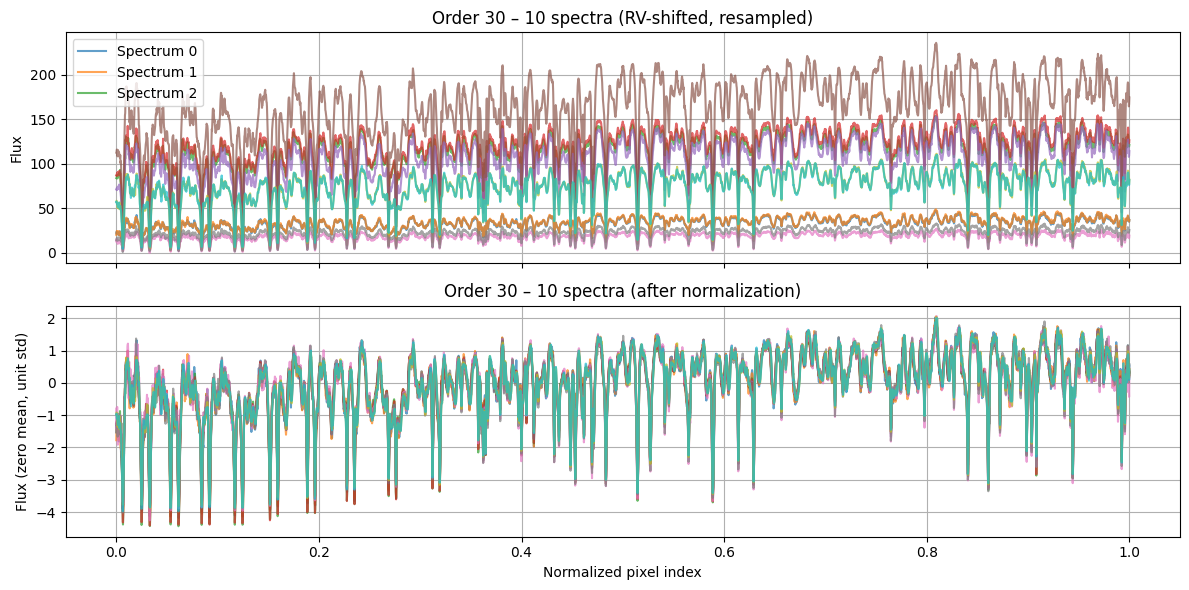

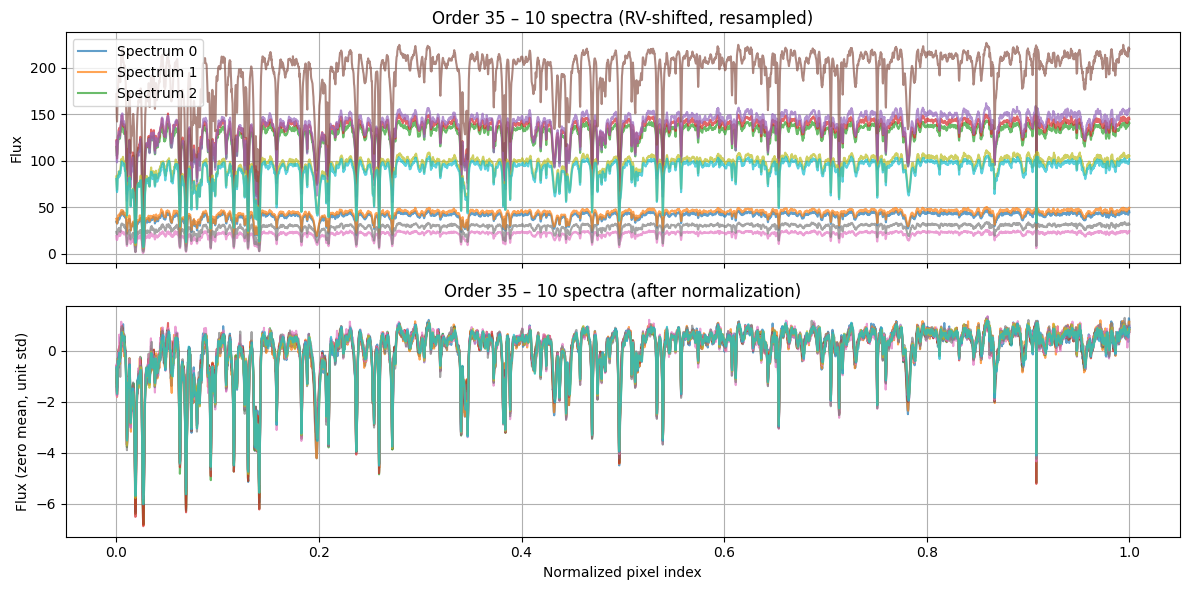

In [ ]:
for order in orders_to_plot:
    normed = processed_with_rv[order]
    raw = resampled_orders[order]
    wave = np.linspace(0, 1, normed.shape[1])

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for i in range(n_examples):
        axs[0].plot(wave, raw[i], alpha=0.7, label=f"Spectrum {i}" if i < 3 else None)
        axs[1].plot(wave, normed[i], alpha=0.7)

    axs[0].set_title(f"Order {order} – {n_examples} spectra (RV-shifted, resampled)")
    axs[1].set_title(f"Order {order} – {n_examples} spectra (after normalization: mean and variance)")
    axs[1].set_xlabel("Normalized pixel index")
    axs[0].set_ylabel("Flux")
    axs[1].set_ylabel("Flux (zero mean, unit std)")
    axs[0].grid(); axs[1].grid()
    if n_examples <= 10:
        axs[0].legend()
    plt.tight_layout()
    plt.show()